In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brsahan/vehicle-co2-emissions-dataset")

# print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-co2-emissions-dataset' dataset.


In [2]:
import pandas as pd
import os

# Assuming the main data file is 'co2.csv'
file_name = 'co2.csv'
full_file_path = os.path.join(path, file_name)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(full_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


Контурниот график на густина (jointplot од библиотеката seaborn со опцијата kind="kde") ни дава претстава за распределбата на податоците и можни области на концентрација на зависностите. Оваа визуелизација ни помага да го истражиме односот помеѓу атрибутите и излезните вредности и да забележиме можни зависности или корелации помеѓу нив. Ќе прикажеме еден ваков график за првиот атрибут со излезната променлива (се создава контурен график на густина помеѓу атрибутот X[:, 0] и излезните вредности y).

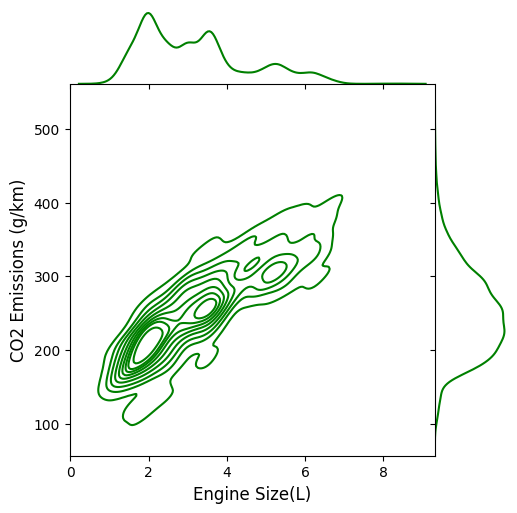

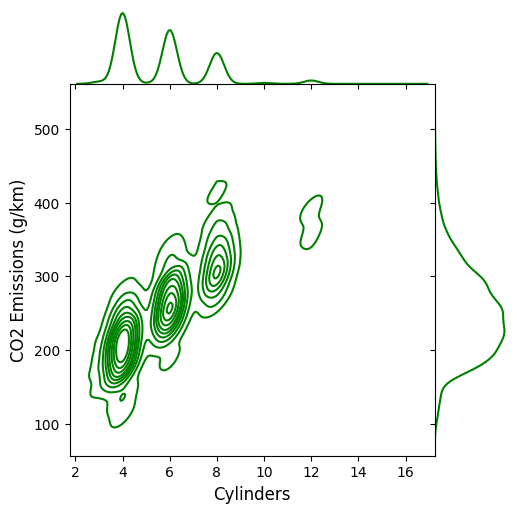

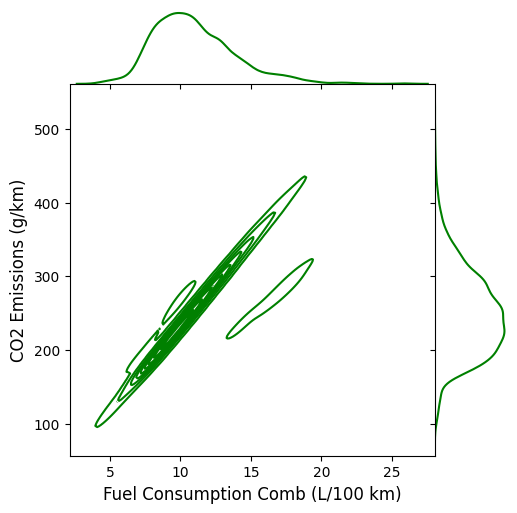

In [3]:
# import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# # 1. Вчитување на податоците (провери ја патеката до твојот фајл)
# df = pd.read_csv('co2.csv')

# 2. Избор на атрибути (Features) и Таргет (Target)
# Ги избираме само нумеричките колони за почеток
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']
target = 'CO2 Emissions(g/km)'

X = df[features].values
y = df[target].values

# 3. Визуелизација со KDE jointplot (според барањето од предавањата)
# Овој приказ покажува каде е најголемата густина на возила
for i, feature_name in enumerate(features):
    g = sns.jointplot(x=X[:, i], y=y, kind="kde", space=0, color="g", height=5)
    g.set_axis_labels(feature_name, 'CO2 Emissions (g/km)', fontsize=12)
    plt.show()

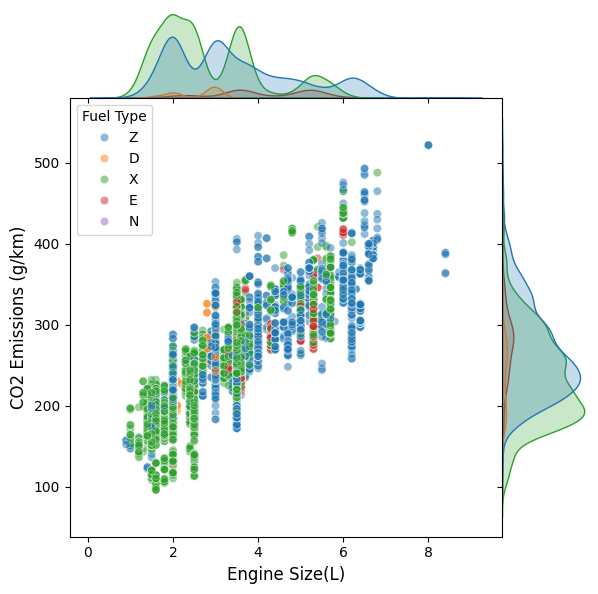

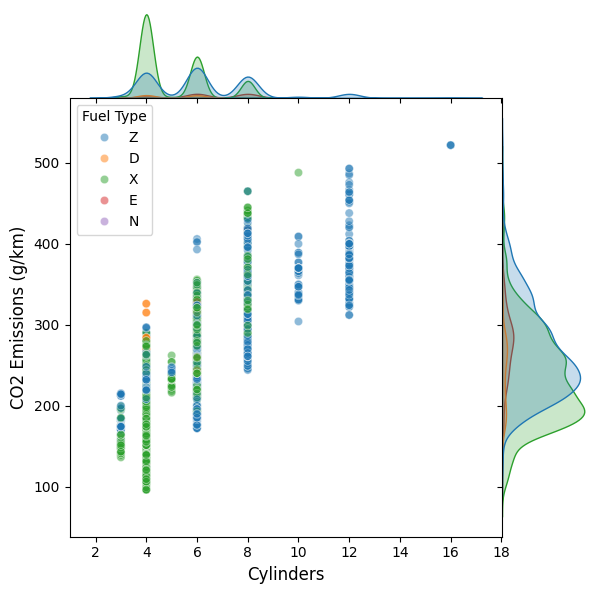

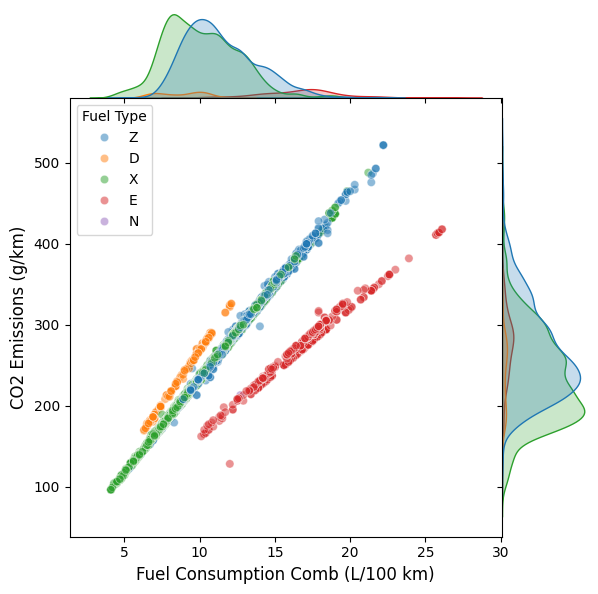

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Вчитување на податоците
# df = pd.read_csv('co2.csv')

# 2. Дефинирање на колоните
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']
target = 'CO2 Emissions(g/km)'
group_col = 'Fuel Type'  # Ова е колоната за групирање

# 3. Визуелизација со KDE jointplot и HUE
for feature_name in features:
    # Забележи: сега користиме data=df и ги пишуваме имињата на колоните како стрингови
    g = sns.jointplot(
        data=df,
        x=feature_name,
        y=target,
        hue=group_col,  # Додавање на боја по тип на гориво
        kind="scatter",
        space=0,
        height=6,
        alpha=0.5 # Додаваме малку прозирна боја за подобро да се гледа каде се преклопуваат
    )

    g.set_axis_labels(feature_name, 'CO2 Emissions (g/km)', fontsize=12)
    plt.show()

### Нормализација на податоците
Ќе направиме мин-макс нормализација на податоците со MinMaxScaler() објект, како и во претходниот пример за едноставна линеарна регресија. Потоа, ги делиме нормализираните податоци во две групи - тренирачка група и тест група. X_train содржи тренирачки влезни податоци (обележени со X) кои се користат за обучување на моделот, X_test содржи тест влезни податоци (обележени со X) кои се користат за проверка на моделот, y_train содржи тренирачки излезни податоци (обележени со y) кои се користат за обучување на моделот, a y_test содржи тест излезни податоци (обележени со y) кои се користат за проверка на моделот. Го поставуваме односот помеѓу тренирачките и тест податоци на 30% за тест.

In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
#Забележете дека бидејќи ова е малo податочно множество, не треба да го користиме стандардниот train_test_split
#за да ја процениме точноста на множеството податоци, туку треба да користиме вкрстена валидација.
#Меѓутоа, за едноставност, го правиме тоа во овој пример.

In [9]:
# 2. Избор на влезни атрибути (X) и таргет променлива (y)
# Ги земаме само нумеричките колони како што почнавме во претходните чекори
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']
target = 'CO2 Emissions(g/km)'

X = df[features].values
y = df[target].values

# 3. Примена на MinMaxScaler
# Ова ги трансформира вредностите во опсег од 0 до 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 4. Поделба на податоците (Train-Test Split)
# Користиме 30% за тест множество како што наведовме претходно
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

# Проверка на резултатот
print("Првите 5 реда од оригиналните податоци (X):")
print(X[:5])
print("\nПрвите 5 реда по Min-Max нормализација (X_scaled):")
print(X_scaled[:5])

Првите 5 реда од оригиналните податоци (X):
[[ 2.   4.   8.5]
 [ 2.4  4.   9.6]
 [ 1.5  4.   5.9]
 [ 3.5  6.  11.1]
 [ 3.5  6.  10.6]]

Првите 5 реда по Min-Max нормализација (X_scaled):
[[0.14666667 0.07692308 0.2       ]
 [0.2        0.07692308 0.25      ]
 [0.08       0.07692308 0.08181818]
 [0.34666667 0.23076923 0.31818182]
 [0.34666667 0.23076923 0.29545455]]


--- LINEAR REGRESSION РЕЗУЛТАТИ ---
Коефициенти W:  [ 40.33672911  83.32127993 293.68219637]
Пресек W0:  129.98744339131736
Средна квадратна грешка: 421.6248645242684
Средна апсолутна грешка: 13.466122981652617
Корен на средна квадратна грешка: 20.53350589948702
R-квадрат:  0.8751741796784172


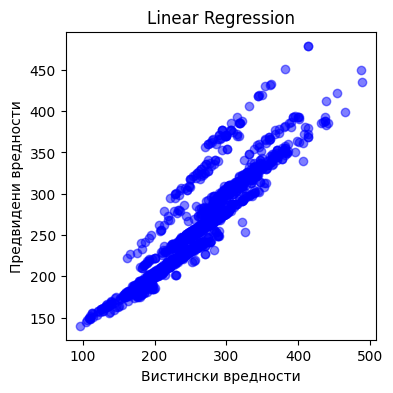

In [11]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, BayesianRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Иницијализација и тренирање на најобичниот линеарен модел
reg_linear = LinearRegression().fit(X_train, y_train)

print("--- LINEAR REGRESSION РЕЗУЛТАТИ ---")
print("Коефициенти W: ", reg_linear.coef_)
print("Пресек W0: ", reg_linear.intercept_)

y_pred = reg_linear.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.title("Linear Regression")
plt.show()

--- RIDGE CV РЕЗУЛТАТИ ---
Најдобар Alpha:  0.1
Коефициенти W:  [ 41.00518754  83.09452649 292.79238934]
Пресек W0:  130.10999250563395
Средна квадратна грешка: 421.5781304094295
Средна апсолутна грешка: 13.484193465480836
Корен на средна квадратна грешка: 20.532367871471365
R-квадрат:  0.8751880157320102


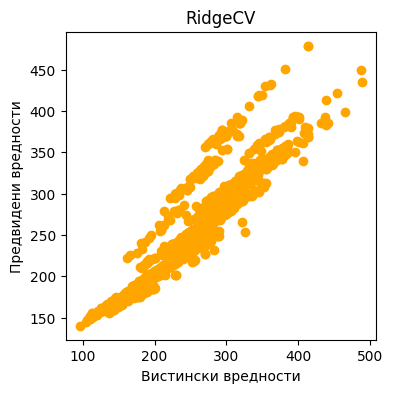

In [22]:
# Иницијализација и тренирање со автоматско наоѓање на Alpha
reg_ridge = RidgeCV(alphas=[0.1, 1.0, 10.0]).fit(X_train, y_train)

print("--- RIDGE CV РЕЗУЛТАТИ ---")
print("Најдобар Alpha: ", reg_ridge.alpha_)
print("Коефициенти W: ", reg_ridge.coef_)
print("Пресек W0: ", reg_ridge.intercept_)

y_pred = reg_ridge.predict(X_test)
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred))

plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='orange')
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.title("RidgeCV")
plt.show()

--- LASSO CV РЕЗУЛТАТИ ---
Најдобар Alpha:  0.009076355356612699
Коефициенти W:  [ 41.13339817  82.42092564 293.02157403]
Пресек W0:  130.13587202902912
Средна квадратна грешка: 421.6311992638773
Средна апсолутна грешка: 13.481328135780975
Корен на средна квадратна грешка: 20.533660152634194
R-квадрат:  0.8751723042219752


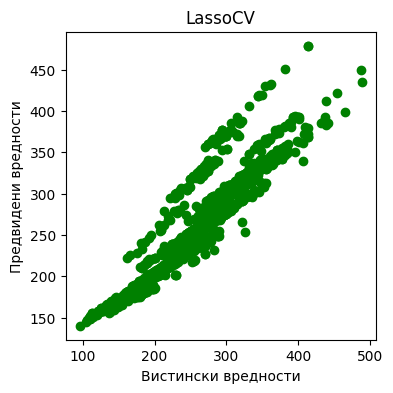

In [13]:
# Иницијализација и тренирање со автоматско наоѓање на Alpha
reg_lasso = LassoCV(cv=5, random_state=42).fit(X_train, y_train)

print("--- LASSO CV РЕЗУЛТАТИ ---")
print("Најдобар Alpha: ", reg_lasso.alpha_)
print("Коефициенти W: ", reg_lasso.coef_)
print("Пресек W0: ", reg_lasso.intercept_)

y_pred = reg_lasso.predict(X_test)
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred))

plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='green')
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.title("LassoCV")
plt.show()

--- ELASTIC NET CV РЕЗУЛТАТИ ---
Најдобар Alpha:  0.018152710713225398
Коефициенти W:  [ 99.9815296   80.34912385 149.79595489]
Пресек W0:  157.6409470872079
Средна квадратна грешка: 562.3440209085103
Средна апсолутна грешка: 17.714726390622328
Корен на средна квадратна грешка: 23.713793895294575
R-квадрат:  0.8335130121131606


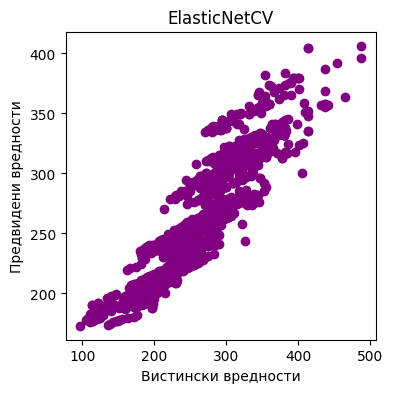

In [14]:
# Комбинација од Ridge и Lasso регуларизација
reg_elastic = ElasticNetCV(cv=5, random_state=42).fit(X_train, y_train)

print("--- ELASTIC NET CV РЕЗУЛТАТИ ---")
print("Најдобар Alpha: ", reg_elastic.alpha_)
print("Коефициенти W: ", reg_elastic.coef_)
print("Пресек W0: ", reg_elastic.intercept_)

y_pred = reg_elastic.predict(X_test)
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred))

plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='purple')
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.title("ElasticNetCV")
plt.show()

--- BAYESIAN RIDGE РЕЗУЛТАТИ ---
Коефициенти W:  [ 40.42418638  83.29135925 293.56620571]
Пресек W0:  130.00339467885448
Средна квадратна грешка: 421.6182159240874
Средна апсолутна грешка: 13.468474712803582
Корен на средна квадратна грешка: 20.533344002477712
R-квадрат:  0.8751761480560946


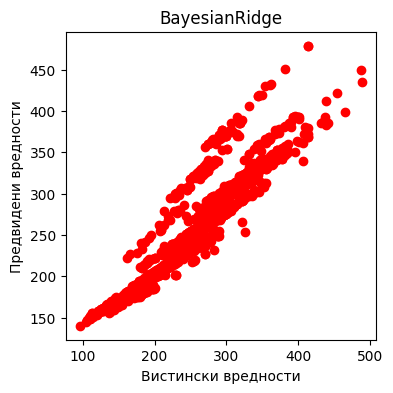

In [15]:
# Статистички пристап кон регуларизација
reg_bayesian = BayesianRidge().fit(X_train, y_train)

print("--- BAYESIAN RIDGE РЕЗУЛТАТИ ---")
print("Коефициенти W: ", reg_bayesian.coef_)
print("Пресек W0: ", reg_bayesian.intercept_)

y_pred = reg_bayesian.predict(X_test)
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred))

plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='red')
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.title("BayesianRidge")
plt.show()

In [16]:
# Овој дел оди на крајот, откако ќе ги извршиш сите 5 модели
print("\n=== ФИНАЛНА СПОРЕДБА НА MSE ===")

# Замени ги променливите со имињата што ги користеше во кодот
sporedba_mse = {
    "Linear Regression": mean_squared_error(y_test, reg_linear.predict(X_test)),
    "Ridge CV": mean_squared_error(y_test, reg_ridge.predict(X_test)),
    "Lasso CV": mean_squared_error(y_test, reg_lasso.predict(X_test)),
    "ElasticNet CV": mean_squared_error(y_test, reg_elastic.predict(X_test)),
    "Bayesian Ridge": mean_squared_error(y_test, reg_bayesian.predict(X_test))
}

# Печатење на табелата
for model, mse_val in sporedba_mse.items():
    print(f"{model:20} | MSE: {mse_val:.4f}")


=== ФИНАЛНА СПОРЕДБА НА MSE ===
Linear Regression    | MSE: 421.6249
Ridge CV             | MSE: 421.5781
Lasso CV             | MSE: 421.6312
ElasticNet CV        | MSE: 562.3440
Bayesian Ridge       | MSE: 421.6182


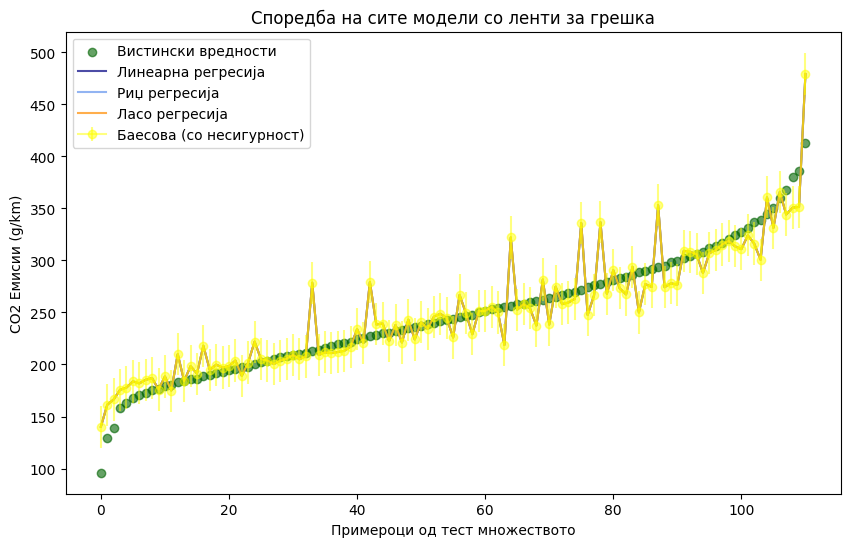

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Бидејќи веќе ги имаме X_train, X_test, y_train, y_test од MinMaxScaler:
N = len(y_train)

# 1. Тренирање на моделите (идентично како во примерот од час)
lr = LinearRegression().fit(X_train, y_train)
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0]).fit(X_train, y_train)
lasso = LassoCV(cv=5).fit(X_train, y_train)
elastic = ElasticNetCV(cv=5).fit(X_train, y_train)
Bayes = BayesianRidge().fit(X_train, y_train)

# 2. Пресметка на грешката (sigma) за лентите на графикот
# Сигма за линеарна регресија
lr_predictions = lr.predict(X_train)
lr_sigma = np.sqrt(np.sum((y_train - lr_predictions)**2) / (N - X_train.shape[1]))

# 3. Подготовка за визуелизација
# Бидејќи имаме 3 влезни атрибути, ќе направиме споредба: Вистински vs Предвидени вредности
y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_elastic = elastic.predict(X_test)
y_pred_bayes, bayes_sigma = Bayes.predict(X_test, return_std=True)

# Сортирање на тест податоците за поубава линија на графикот
sort_idx = np.argsort(y_test)
y_test_sorted = y_test[sort_idx]
# Земаме само мал дел (пр. 50 точки) за прегледност на errorbar
sample_idx = sort_idx[::20]

plt.figure(figsize=(10, 6))

# Цртање на вистинските вредности како точки
plt.scatter(range(len(sample_idx)), y_test[sample_idx], color='darkgreen', label='Вистински вредности', alpha=0.6)

# Цртање на линиите за предвидување на секој модел
plt.plot(range(len(sample_idx)), y_pred_lr[sample_idx], color='navy', label='Линеарна регресија', alpha=0.7)
plt.plot(range(len(sample_idx)), y_pred_ridge[sample_idx], color='cornflowerblue', label='Риџ регресија', alpha=0.7)
plt.plot(range(len(sample_idx)), y_pred_lasso[sample_idx], color='darkorange', label='Ласо регресија', alpha=0.7)

# Додавање на errorbar за Баесовиот модел (како во примерот од час)
plt.errorbar(range(len(sample_idx)), y_pred_bayes[sample_idx], yerr=bayes_sigma[sample_idx],
             fmt='-o', color='yellow', label='Баесова (со несигурност)', alpha=0.5)

plt.legend(loc='best')
plt.title("Споредба на сите модели со ленти за грешка")
plt.ylabel("CO2 Емисии (g/km)")
plt.xlabel("Примероци од тест множеството")
plt.show()